<h1>SPTech — Análise de Dados</h1>
<h1>EDA — Análise Exploratória de Dados</h1>

Este notebook executa um roteiro completo de EDA sobre **qualquer base tabular**.

Para usar na base do seu Projeto de Inovação, altere **apenas a célula de configuração** logo abaixo e execute tudo (`Executar tudo` / `Run all`). Nenhuma outra célula precisa ser editada.

O roteiro segue a ordem apresentada na Aula 6:

| Seção | Conteúdo |
| --- | --- |
| 0 | Configuração e carga |
| 1 | Estrutura, grão e chave |
| 2 | Qualidade: nulos, nulos disfarçados, duplicatas |
| 3 | Univariada numérica: centro, dispersão, forma, extremos |
| 4 | Univariada categórica: frequência, cardinalidade, cauda longa |
| 5 | Outliers: IQR, z-score e z-score modificado |
| 6 | Séries temporais: tendência, sazonalidade, quebras |
| 7 | Bivariada: o gráfico certo para cada par de tipos |
| 8 | Correlação: Pearson, Spearman e o alerta de Anscombe |
| 9 | Segmentação com o n ao lado |
| 10 | Multivariada: facetas, confundimento e teste de Simpson |
| 11 | Síntese: achados, hipóteses e decisões |

---

# 0) Configuração

**Esta é a única célula que você precisa alterar.**

Preencha o caminho do arquivo e, se quiser, indique as colunas que têm papel especial. Tudo o que ficar vazio é detectado automaticamente.

In [1]:
# ═══════════════════════════════════════════════════════════════════
#  CONFIGURAÇÃO — altere apenas esta célula
# ═══════════════════════════════════════════════════════════════════

CAMINHO  = "dados/gold/base_eda_pedidos.csv"   # caminho do seu arquivo
SEP      = ","            # separador de campos: "," ou ";" ou "\t"
ENCODING = "utf-8-sig"    # "utf-8", "utf-8-sig" ou "latin1"
DECIMAL  = "."            # "." ou "," conforme o arquivo

# Opcionais — deixe como está para detecção automática
COLS_DATA    = ["dt_hr_pedido"]   # ex: ["dt_agendamento", "dt_consulta"]
COL_ALVO     = "atrasou"          # variável de interesse, ex: "situacao"
COLS_IGNORAR = ["id_pedido"]      # identificadores a excluir das análises numéricas
GRAO         = ["id_pedido"]      # colunas que identificam uma linha, ex: ["id_pedido"]

# Valores que devem ser lidos como ausentes
NA_EXTRA = ["", "-", "--", "N/A", "NA", "n/a", "não informado",
            "nao informado", "sem dado", "null", "NULL", "?", "#N/D"]

# Ajustes de exibição
MAX_CATEGORIAS  = 15      # categorias mostradas nos gráficos de barras
MIN_N_SEGMENTO  = 30      # n mínimo para um segmento ser considerado confiável
# ═══════════════════════════════════════════════════════════════════

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12

print("Bibliotecas carregadas. Pandas", pd.__version__)

Bibliotecas carregadas. Pandas 3.0.6


## 0.1) Carga

A leitura é feita **com tudo como texto**, como vimos na Aula 5: a conversão de tipos é decisão nossa, não palpite da biblioteca. A conversão acontece na célula seguinte, e o que não converter fica registrado.

In [3]:
df_bruto = pd.read_csv(
    CAMINHO,
    sep=SEP,
    encoding=ENCODING,
    dtype=str,
    na_values=NA_EXTRA,
    keep_default_na=True,
)

print(f"Arquivo: {CAMINHO}")
print(f"Linhas: {df_bruto.shape[0]:,}   Colunas: {df_bruto.shape[1]}".replace(",", "."))
df_bruto.head()

Arquivo: dados/gold/base_eda_pedidos.csv
Linhas: 16.849   Colunas: 22


,id_pedido,dt_hr_pedido,pedidos_na_hora,tempo_espera_min,valor_total,qtd_itens,hora,temperatura_hora_c,chuva_hora_mm,temp_max_dia_c,chuva_dia_mm,tipo_dia,periodo,dia_semana,dia_chuvoso,condicao_dia,faixa_temperatura,vespera_ou_ponte,tem_bebida_gelada,status,atrasou,descricao
0,1,01/04/2026 09:00:47,8,4.4,37.0,3,9,20.4,0.0,25.2,15.6,dia útil,manhã (até 12h),Quarta-feira,sim,Chuva forte,Ameno,não,sim,Pronto,não,NaN
1,2,01/04/2026 09:05:30,8,3.2,14.0,1,9,20.4,0.0,25.2,15.6,dia útil,manhã (até 12h),Quarta-feira,sim,Chuva forte,Ameno,não,não,Pronto,não,NaN
2,3,01/04/2026 09:15:19,8,1.9,12.0,1,9,20.4,0.0,25.2,15.6,dia útil,manhã (até 12h),Quarta-feira,sim,Chuva forte,Ameno,não,não,Pronto,não,NaN
3,4,01/04/2026 09:42:28,8,3.0,16.0,1,9,20.4,0.0,25.2,15.6,dia útil,manhã (até 12h),Quarta-feira,sim,Chuva forte,Ameno,não,sim,Pronto,não,NaN
4,5,01/04/2026 09:44:45,8,2.1,10.0,1,9,20.4,0.0,25.2,15.6,dia útil,manhã (até 12h),Quarta-feira,sim,Chuva forte,Ameno,não,não,Pronto,não,NaN


## 0.2) Conversão de tipos

Cada coluna é testada: se a maior parte dos valores válidos converte para número, ela vira numérica; se converte para data, vira datetime; caso contrário permanece como texto.

O relatório mostra **quanto se perdeu** em cada conversão. Perda alta é sinal de que a coluna precisa de limpeza antes, não de conversão.

In [4]:
import re

def tenta_numero(serie, decimal=DECIMAL):
    """Converte para número tratando separador decimal e de milhar.

    O separador de milhar só é removido quando está em posição de milhar
    (seguido de exatamente três dígitos). Isso evita que "999.0" vire 9990
    numa base configurada com decimal vírgula.
    """
    s = serie.astype(str).str.strip()
    if decimal == ",":
        s = s.str.replace(r"\.(?=\d{3}(\D|$))", "", regex=True)
        s = s.str.replace(",", ".", regex=False)
    else:
        s = s.str.replace(r",(?=\d{3}(\D|$))", "", regex=True)
    return pd.to_numeric(s, errors="coerce")


def tenta_data(serie):
    return pd.to_datetime(serie, errors="coerce", dayfirst=True)


df = df_bruto.copy()
relatorio_conversao = []

for col in df.columns:
    validos = df[col].notna().sum()
    if validos == 0:
        relatorio_conversao.append([col, "vazia", 0, 0.0])
        continue

    if col in COLS_DATA:
        conv = tenta_data(df[col])
        df[col] = conv
        perda = (df_bruto[col].notna() & conv.isna()).sum()
        relatorio_conversao.append([col, "datetime", validos, round(perda / validos * 100, 1)])
        continue

    num = tenta_numero(df[col])
    taxa_num = num.notna().sum() / validos

    if taxa_num >= 0.90:
        df[col] = num
        perda = (df_bruto[col].notna() & num.isna()).sum()
        relatorio_conversao.append([col, "numérica", validos, round(perda / validos * 100, 1)])
        continue

    dat = tenta_data(df[col])
    if dat.notna().sum() / validos >= 0.90:
        df[col] = dat
        perda = (df_bruto[col].notna() & dat.isna()).sum()
        relatorio_conversao.append([col, "datetime", validos, round(perda / validos * 100, 1)])
        continue

    relatorio_conversao.append([col, "texto", validos, 0.0])

rel_conv = pd.DataFrame(relatorio_conversao,
                        columns=["coluna", "tipo_final", "validos", "perda_pct"])
rel_conv.sort_values("perda_pct", ascending=False).head(20)

,coluna,tipo_final,validos,perda_pct
0,id_pedido,numérica,16849,0.0
1,dt_hr_pedido,datetime,16849,0.0
2,pedidos_na_hora,numérica,16849,0.0
3,tempo_espera_min,numérica,16736,0.0
4,valor_total,numérica,16849,0.0
5,qtd_itens,numérica,16849,0.0
6,hora,numérica,16849,0.0
7,temperatura_hora_c,numérica,16849,0.0
8,chuva_hora_mm,numérica,16849,0.0
9,temp_max_dia_c,numérica,16849,0.0


→ **Leia a coluna perda_pct.** Valor acima de 1% significa que parte dos dados não converteu e virou nulo. Antes de seguir, investigue: é sujeira pontual ou é a coluna inteira em outro formato?

In [5]:
# Classificação das colunas por papel na análise
COLS_NUM = [c for c in df.select_dtypes(include="number").columns
            if c not in COLS_IGNORAR]
COLS_CAT = [c for c in df.select_dtypes(include=["object", "category"]).columns
            if c not in COLS_IGNORAR]
COLS_DT  = list(df.select_dtypes(include="datetime").columns)

# Identificadores disfarçados de número.
# Critério: quase todos os valores distintos E sem casas decimais.
# Variável contínua legítima (valor, peso, tempo) tem decimais e escapa daqui.
PADRAO_ID = ("id", "cod", "cpf", "cnpj", "cep", "matric", "protocolo",
             "registro", "numero", "num_", "_ra", "chave")

def parece_identificador(serie, nome):
    s = serie.dropna()
    if s.empty:
        return False
    quase_unico = s.nunique() > 0.95 * len(s)
    inteiro = (s % 1 == 0).all()
    nome_sugere = any(p in nome.lower() for p in PADRAO_ID)
    return quase_unico and (inteiro or nome_sugere)

possiveis_id = [c for c in COLS_NUM if parece_identificador(df[c], c)]
COLS_NUM = [c for c in COLS_NUM if c not in possiveis_id]

print(f"Numéricas   ({len(COLS_NUM)}): {COLS_NUM}")
print()
print(f"Categóricas ({len(COLS_CAT)}): {COLS_CAT}")
print()
print(f"Datas       ({len(COLS_DT)}): {COLS_DT}")
print()
if possiveis_id:
    print(f"Excluídas por parecerem identificadores: {possiveis_id}")

Numéricas   (9): ['pedidos_na_hora', 'tempo_espera_min', 'valor_total', 'qtd_itens', 'hora', 'temperatura_hora_c', 'chuva_hora_mm', 'temp_max_dia_c', 'chuva_dia_mm']

Categóricas (11): ['tipo_dia', 'periodo', 'dia_semana', 'dia_chuvoso', 'condicao_dia', 'faixa_temperatura', 'vespera_ou_ponte', 'tem_bebida_gelada', 'status', 'atrasou', 'descricao']

Datas       (1): ['dt_hr_pedido']



---
# 1) Estrutura, grão e chave

A pergunta da Aula 5 que abre toda EDA: **o que representa uma linha desta tabela?**

In [6]:
print("=" * 60)
print("ESTRUTURA DA BASE")
print("=" * 60)
print(f"Linhas:   {df.shape[0]:,}".replace(",", "."))
print(f"Colunas:  {df.shape[1]}")
print(f"Memória:  {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
df.info()

ESTRUTURA DA BASE
Linhas:   16.849
Colunas:  22
Memória:  12.98 MB

<class 'pandas.DataFrame'>
RangeIndex: 16849 entries, 0 to 16848
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           16849 non-null  int64         
 1   dt_hr_pedido        16849 non-null  datetime64[us]
 2   pedidos_na_hora     16849 non-null  int64         
 3   tempo_espera_min    16736 non-null  float64       
 4   valor_total         16849 non-null  float64       
 5   qtd_itens           16849 non-null  int64         
 6   hora                16849 non-null  int64         
 7   temperatura_hora_c  16849 non-null  float64       
 8   chuva_hora_mm       16849 non-null  float64       
 9   temp_max_dia_c      16849 non-null  float64       
 10  chuva_dia_mm        16849 non-null  float64       
 11  tipo_dia            16849 non-null  str           
 12  periodo             16849 non-null  str      

In [7]:
# Verificação do grão declarado na configuração
if GRAO:
    dup = df.duplicated(subset=GRAO).sum()
    print(f"Grão declarado: {GRAO}")
    print(f"Linhas duplicadas nesse grão: {dup}")
    if dup == 0:
        print("OK — a chave declarada identifica unicamente cada linha.")
    else:
        print("ATENÇÃO — a chave declarada NÃO é única. O grão real é mais fino.")
else:
    print("Nenhum grão declarado em GRAO.")
    print("Candidatos a chave única (colunas sem valores repetidos):")
    print()
    for col in df.columns:
        if df[col].notna().all() and df[col].nunique() == len(df):
            print(f"   {col}")

Grão declarado: ['id_pedido']
Linhas duplicadas nesse grão: 0
OK — a chave declarada identifica unicamente cada linha.


---
# 2) Qualidade: nulos, disfarçados e duplicatas

In [8]:
def relatorio_qualidade(df):
    rel = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "pct_nulos": (df.isna().mean() * 100).round(1),
        "distintos": df.nunique(dropna=True),
        "pct_distintos": (df.nunique(dropna=True) / len(df) * 100).round(1),
    })
    return rel.sort_values("pct_nulos", ascending=False)


qualidade = relatorio_qualidade(df)
qualidade

,tipo,nulos,pct_nulos,distintos,pct_distintos
descricao,str,13808,82.0,1,0.0
tempo_espera_min,float64,113,0.7,297,1.8
atrasou,str,113,0.7,2,0.0
pedidos_na_hora,int64,0,0.0,30,0.2
dt_hr_pedido,datetime64[us],0,0.0,16826,99.9
id_pedido,int64,0,0.0,16849,100.0
qtd_itens,int64,0,0.0,7,0.0
valor_total,float64,0,0.0,101,0.6
hora,int64,0,0.0,9,0.1
temperatura_hora_c,float64,0,0.0,199,1.2


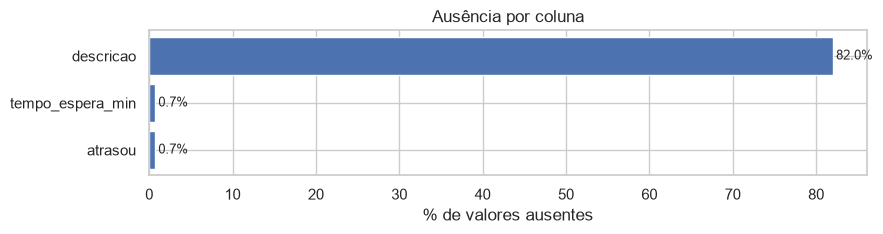

In [9]:
# Gráfico dos nulos por coluna
com_nulos = qualidade[qualidade["pct_nulos"] > 0]

if len(com_nulos):
    fig, ax = plt.subplots(figsize=(9, max(2.5, 0.32 * len(com_nulos))))
    ax.barh(com_nulos.index[::-1], com_nulos["pct_nulos"][::-1])
    ax.set_xlabel("% de valores ausentes")
    ax.set_title("Ausência por coluna")
    for i, v in enumerate(com_nulos["pct_nulos"][::-1]):
        ax.text(v + 0.4, i, f"{v}%", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma coluna com valores ausentes.")

## 2.1) O mapa da ausência

Cada linha do gráfico é uma linha da base; cada coluna, uma coluna. As marcas escuras são valores ausentes.

**O que procurar:** faixas horizontais contínuas. Ausência em bloco nunca é acaso — é troca de sistema, mudança de formulário ou falha de carga em um período.

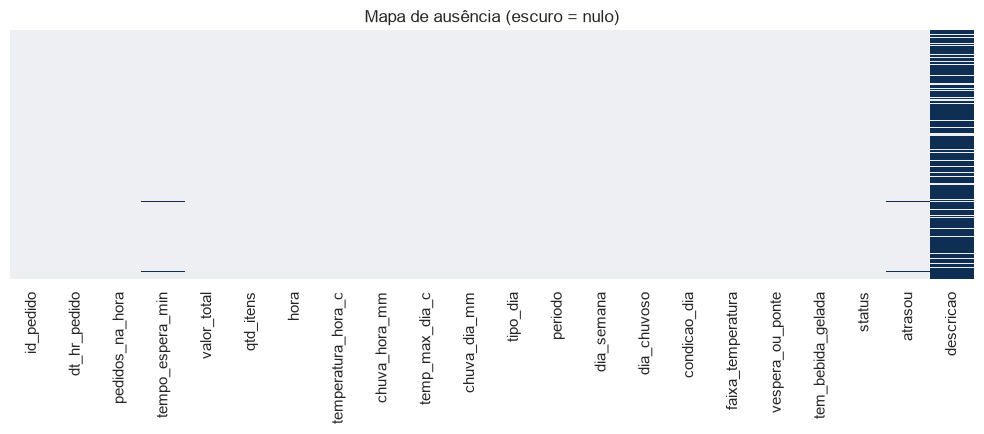

In [10]:
if df.isna().any().any():
    amostra = df if len(df) <= 500 else df.sample(500, random_state=42).sort_index()
    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.heatmap(amostra.isna(), cbar=False, yticklabels=False,
                cmap=["#EDEFF2", "#0F2E54"], ax=ax)
    ax.set_title("Mapa de ausência (escuro = nulo)")
    plt.tight_layout()
    plt.show()
else:
    print("Base sem valores ausentes — nada a mapear.")

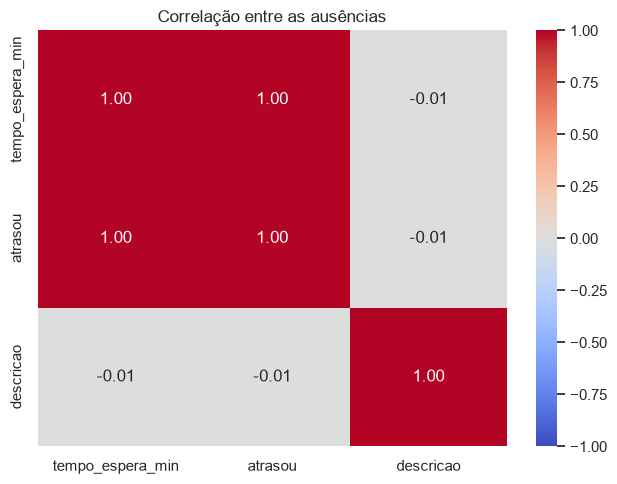

Valores próximos de 1 indicam colunas que faltam sempre juntas —
sinal de que vêm da mesma origem, que falhou.


In [11]:
# Colunas que costumam faltar juntas
nulos_bin = df.isna()
nulos_bin = nulos_bin.loc[:, nulos_bin.any()]

if nulos_bin.shape[1] >= 2:
    co = nulos_bin.corr()
    fig, ax = plt.subplots(figsize=(6.5, 5))
    sns.heatmap(co, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, ax=ax)
    ax.set_title("Correlação entre as ausências")
    plt.tight_layout()
    plt.show()
    print("Valores próximos de 1 indicam colunas que faltam sempre juntas —")
    print("sinal de que vêm da mesma origem, que falhou.")
else:
    print("Menos de duas colunas com ausência — correlação não se aplica.")

## 2.2) Nulos disfarçados

O `isna()` só enxerga o que foi reconhecido como ausente na leitura. O resto está disfarçado de valor.

In [12]:
SUSPEITOS_TEXTO = {"", " ", "-", "--", "n/a", "na", "nao informado",
                   "não informado", "sem dado", "null", "none", "nan",
                   "?", "xx", "zzz", "000", "999", "9999", "sem informacao"}

achados = []
for col in COLS_CAT:
    s = df[col].astype(str).str.strip().str.lower()
    n = s.isin(SUSPEITOS_TEXTO).sum()
    if n:
        exemplos = s[s.isin(SUSPEITOS_TEXTO)].value_counts().head(3).to_dict()
        achados.append([col, n, round(n / len(df) * 100, 1), str(exemplos)])

if achados:
    print("NULOS DISFARÇADOS EM COLUNAS DE TEXTO")
    display(pd.DataFrame(achados, columns=["coluna", "qtd", "pct", "exemplos"]))
else:
    print("Nenhum valor de texto suspeito encontrado.")

Nenhum valor de texto suspeito encontrado.


In [13]:
# Sentinelas numéricas: valores repetidos em excesso nos extremos
SENTINELAS = [-1, 0, 99, 999, 9999, 99999, 999999, 99999999]

achados_num = []
for col in COLS_NUM:
    s = df[col].dropna()
    if s.empty:
        continue
    for v in SENTINELAS:
        n = (s == v).sum()
        if n and n / len(s) > 0.01:
            achados_num.append([col, v, n, round(n / len(s) * 100, 1)])

if achados_num:
    print("CANDIDATOS A SENTINELA NUMÉRICA (mais de 1% dos valores)")
    display(pd.DataFrame(achados_num, columns=["coluna", "valor", "qtd", "pct"]))
    print()
    print("Avalie caso a caso: zero pode ser um valor legítimo ou uma ausência disfarçada.")
else:
    print("Nenhuma sentinela numérica evidente.")

print()
print("Mínimos e máximos — o extremo costuma denunciar:")
if COLS_NUM:
    display(df[COLS_NUM].describe().T[["min", "max"]])

CANDIDATOS A SENTINELA NUMÉRICA (mais de 1% dos valores)


,coluna,valor,qtd,pct
0,chuva_hora_mm,0,12719,75.5
1,chuva_dia_mm,0,8163,48.4



Avalie caso a caso: zero pode ser um valor legítimo ou uma ausência disfarçada.

Mínimos e máximos — o extremo costuma denunciar:


,min,max
pedidos_na_hora,1.0,30.0
tempo_espera_min,0.4,34.4
valor_total,5.0,148.0
qtd_itens,1.0,7.0
hora,9.0,17.0
temperatura_hora_c,11.2,32.6
chuva_hora_mm,0.0,11.0
temp_max_dia_c,12.8,32.6
chuva_dia_mm,0.0,15.6


In [14]:
# Duplicatas
print(f"Linhas totalmente duplicadas: {df.duplicated().sum()}")
if GRAO:
    print(f"Duplicadas no grão {GRAO}: {df.duplicated(subset=GRAO).sum()}")

if df.duplicated().sum():
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10))

Linhas totalmente duplicadas: 0
Duplicadas no grão ['id_pedido']: 0


---
# 3) Univariada numérica

Centro, dispersão, forma e extremos — para cada variável numérica, de uma vez.

In [15]:
def descritiva_completa(df, cols):
    linhas = []
    for c in cols:
        s = df[c].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        media, dp = s.mean(), s.std()
        linhas.append({
            "variavel": c,
            "n": len(s),
            "nulos_pct": round(df[c].isna().mean() * 100, 1),
            "media": round(media, 2),
            "mediana": round(s.median(), 2),
            "desvio": round(dp, 2),
            "cv_pct": round(dp / media * 100, 1) if media else np.nan,
            "min": round(s.min(), 2),
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "max": round(s.max(), 2),
            "iqr": round(q3 - q1, 2),
            "assimetria": round(s.skew(), 2),
            "curtose": round(s.kurtosis(), 2),
        })
    return pd.DataFrame(linhas).set_index("variavel")


if COLS_NUM:
    desc = descritiva_completa(df, COLS_NUM)
    display(desc)
else:
    print("Nenhuma coluna numérica identificada.")

,n,nulos_pct,media,mediana,desvio,cv_pct,min,q1,q3,max,iqr,assimetria,curtose
variavel,,,,,,,,,,,,,
pedidos_na_hora,16849,0.0,12.30,12.0,4.92,40.0,1.0,9.0,15.0,30.0,6.0,0.69,0.42
tempo_espera_min,16736,0.7,5.42,4.2,4.17,77.0,0.4,2.6,7.2,34.4,4.6,2.02,6.11
valor_total,16849,0.0,19.11,16.0,12.23,64.0,5.0,11.0,24.0,148.0,13.0,2.28,8.96
qtd_itens,16849,0.0,1.57,1.0,0.84,53.5,1.0,1.0,2.0,7.0,1.0,1.85,4.31
hora,16849,0.0,12.87,13.0,2.43,18.9,9.0,11.0,15.0,17.0,4.0,-0.01,-1.12
temperatura_hora_c,16849,0.0,21.77,21.7,4.36,20.0,11.2,18.5,25.1,32.6,6.6,-0.01,-0.73
chuva_hora_mm,16849,0.0,0.14,0.0,0.60,423.4,0.0,0.0,0.0,11.0,0.0,9.44,121.00
temp_max_dia_c,16849,0.0,23.91,24.3,4.15,17.4,12.8,20.7,27.3,32.6,6.6,-0.33,-0.58
chuva_dia_mm,16849,0.0,1.27,0.1,2.66,209.3,0.0,0.0,1.2,15.6,1.2,2.95,8.97


## 3.1) Leitura automática da forma

A regra aplicada abaixo é a da Aula 6: assimetria acima de 1 em módulo já pede mediana em vez de média.

In [16]:
if COLS_NUM:
    for c in desc.index:
        a = desc.loc[c, "assimetria"]
        k = desc.loc[c, "curtose"]
        cv = desc.loc[c, "cv_pct"]

        if abs(a) < 0.5:
            forma = "aproximadamente simétrica — a média representa bem"
        elif abs(a) < 1:
            forma = "levemente assimétrica — média e mediana ainda próximas"
        else:
            lado = "à direita" if a > 0 else "à esquerda"
            forma = f"FORTEMENTE assimétrica {lado} — use a mediana"

        cauda = " Caudas pesadas: extremos mais frequentes que o esperado." if k > 3 else ""
        disp = " Dispersão muito alta." if pd.notna(cv) and cv > 100 else ""

        print(f"{c}")
        print(f"   assimetria {a:+.2f} | curtose {k:+.2f} -> {forma}.{cauda}{disp}")
        print()

pedidos_na_hora
   assimetria +0.69 | curtose +0.42 -> levemente assimétrica — média e mediana ainda próximas.

tempo_espera_min
   assimetria +2.02 | curtose +6.11 -> FORTEMENTE assimétrica à direita — use a mediana. Caudas pesadas: extremos mais frequentes que o esperado.

valor_total
   assimetria +2.28 | curtose +8.96 -> FORTEMENTE assimétrica à direita — use a mediana. Caudas pesadas: extremos mais frequentes que o esperado.

qtd_itens
   assimetria +1.85 | curtose +4.31 -> FORTEMENTE assimétrica à direita — use a mediana. Caudas pesadas: extremos mais frequentes que o esperado.

hora
   assimetria -0.01 | curtose -1.12 -> aproximadamente simétrica — a média representa bem.

temperatura_hora_c
   assimetria -0.01 | curtose -0.73 -> aproximadamente simétrica — a média representa bem.

chuva_hora_mm
   assimetria +9.44 | curtose +121.00 -> FORTEMENTE assimétrica à direita — use a mediana. Caudas pesadas: extremos mais frequentes que o esperado. Dispersão muito alta.

temp_max_dia_c


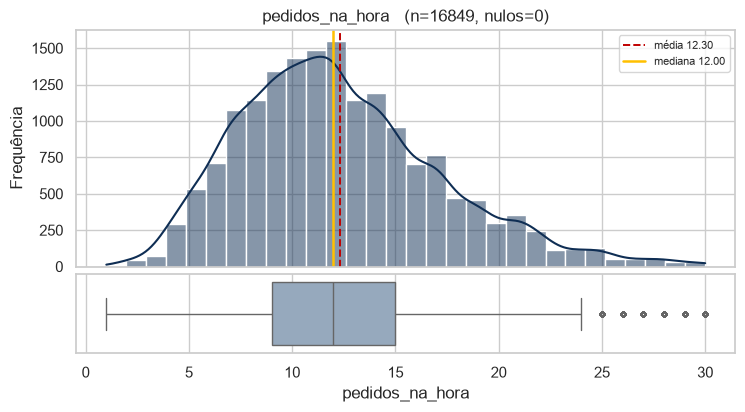

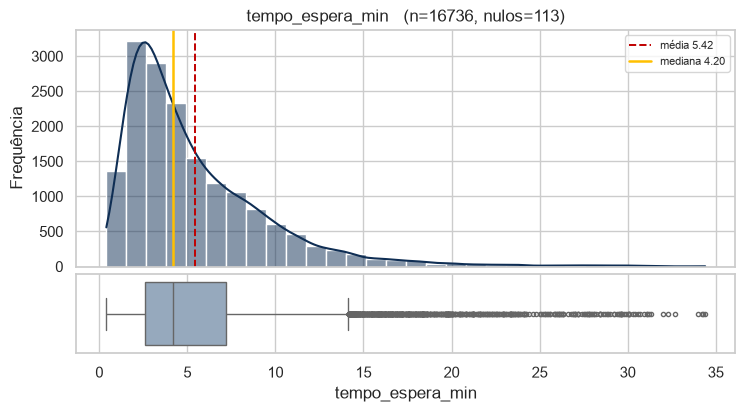

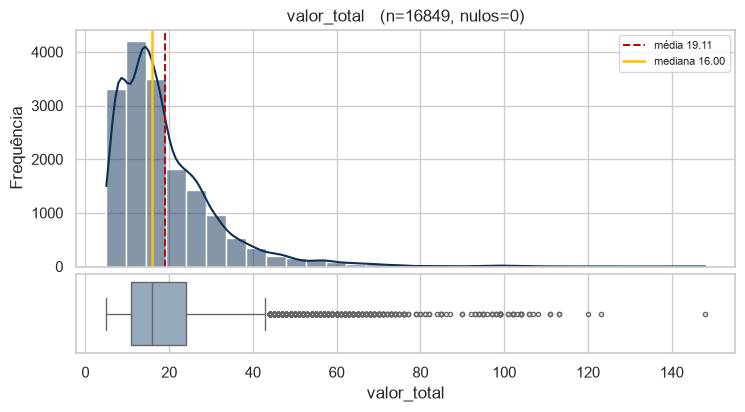

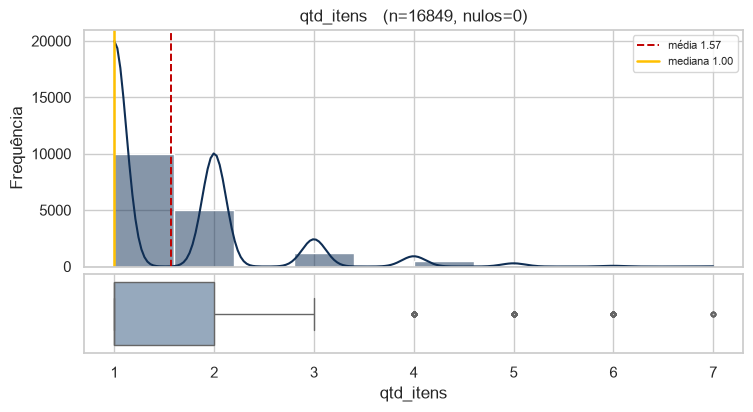

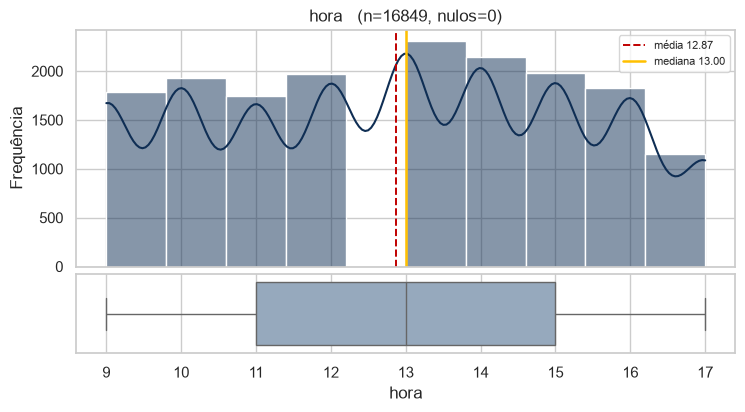

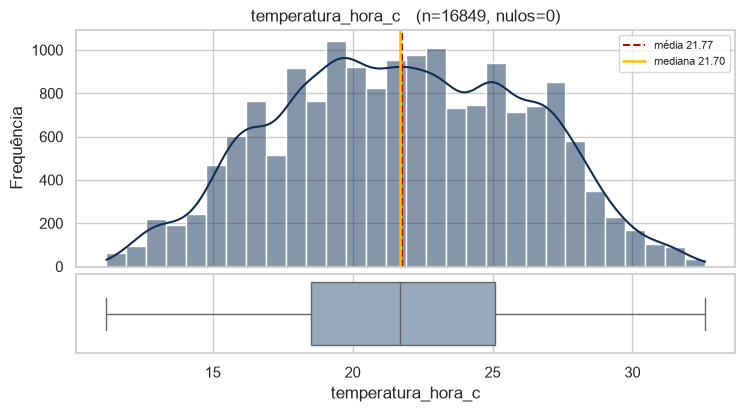

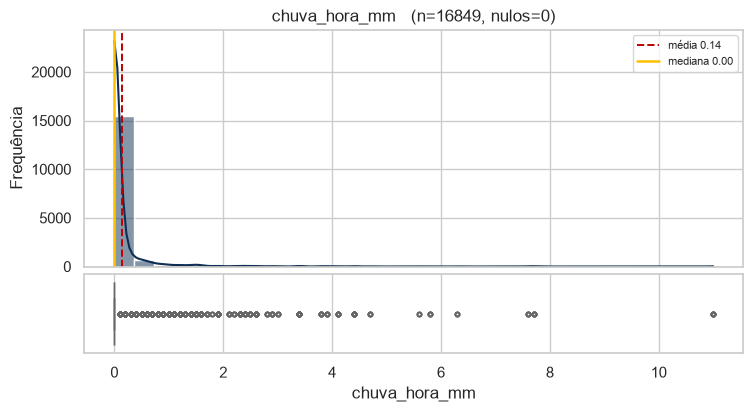

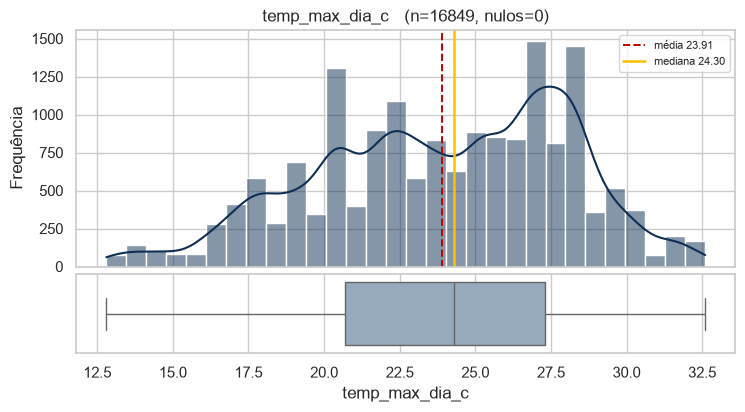

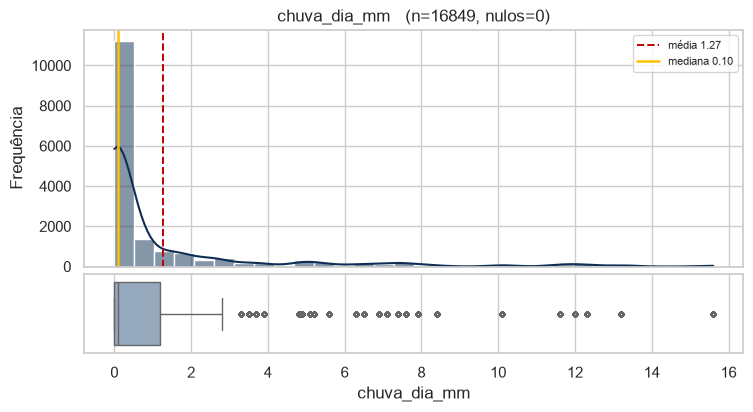

In [17]:
# Histograma + boxplot para cada variável numérica
for c in COLS_NUM:
    s = df[c].dropna()
    if s.empty or s.nunique() < 2:
        continue

    fig, (ax1, ax2) = plt.subplots(
        2, 1, sharex=True, figsize=(8.5, 4.2),
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

    sns.histplot(s, bins=min(30, max(10, s.nunique())), kde=True, ax=ax1,
                 color="#0F2E54")
    ax1.axvline(s.mean(), color="#C00000", ls="--", lw=1.4, label=f"média {s.mean():.2f}")
    ax1.axvline(s.median(), color="#FFC000", ls="-", lw=1.8, label=f"mediana {s.median():.2f}")
    ax1.legend(fontsize=8)
    ax1.set_ylabel("Frequência")
    ax1.set_title(f"{c}   (n={len(s)}, nulos={df[c].isna().sum()})")

    sns.boxplot(x=s, ax=ax2, color="#8FA9C4", fliersize=3)
    ax2.set_xlabel(c)
    plt.tight_layout()
    plt.show()

→ **Onde média e mediana se afastam muito**, a distribuição é assimétrica e a média está sendo puxada por extremos. Reporte a mediana.

→ **Se o histograma tem dois picos**, o boxplot vai escondê-los. Sempre olhe os dois.

---
# 4) Univariada categórica

In [18]:
if COLS_CAT:
    card = pd.DataFrame({
        "distintos": df[COLS_CAT].nunique(dropna=True),
        "nulos_pct": (df[COLS_CAT].isna().mean() * 100).round(1),
        "mais_frequente": [df[c].mode().iloc[0] if not df[c].mode().empty else None
                           for c in COLS_CAT],
        "freq_do_top_pct": [round(df[c].value_counts(normalize=True).iloc[0] * 100, 1)
                            if df[c].notna().any() else np.nan for c in COLS_CAT],
    }).sort_values("distintos", ascending=False)

    card["leitura"] = np.select(
        [card["distintos"] <= 10, card["distintos"] <= 30, card["distintos"] <= 100],
        ["barras simples", "barras horizontais ordenadas", "top N + Outros"],
        default="cardinalidade muito alta: identificador ou texto livre?")
    display(card)
else:
    print("Nenhuma coluna categórica identificada.")

,distintos,nulos_pct,mais_frequente,freq_do_top_pct,leitura
dia_semana,7,0.0,Sábado,18.6,barras simples
condicao_dia,5,0.0,Sol,50.3,barras simples
tipo_dia,3,0.0,dia útil,59.8,barras simples
periodo,3,0.0,tarde (após 14h),42.2,barras simples
faixa_temperatura,3,0.0,Ameno,67.3,barras simples
dia_chuvoso,2,0.0,não,91.2,barras simples
vespera_ou_ponte,2,0.0,não,94.8,barras simples
tem_bebida_gelada,2,0.0,não,72.1,barras simples
status,2,0.0,Pronto,99.3,barras simples
atrasou,2,0.7,não,88.3,barras simples


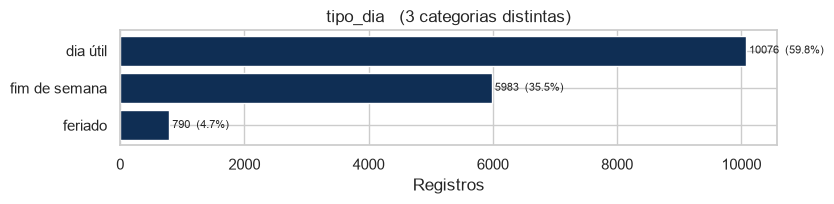

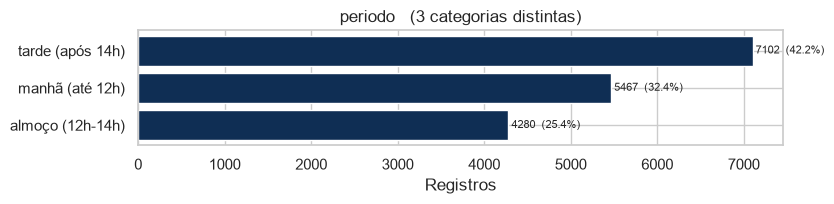

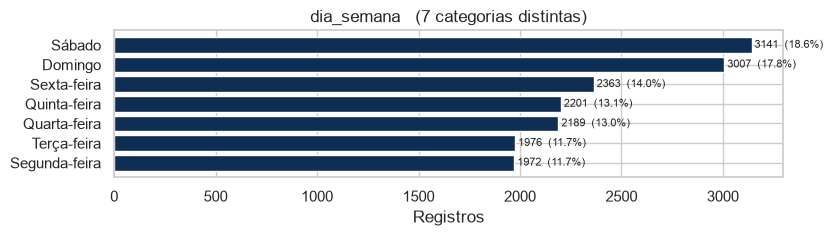

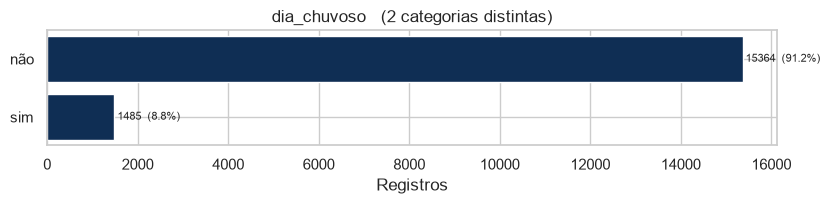

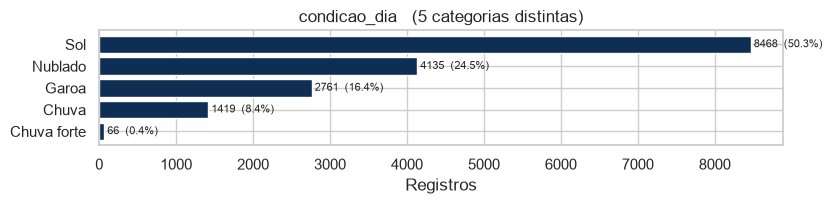

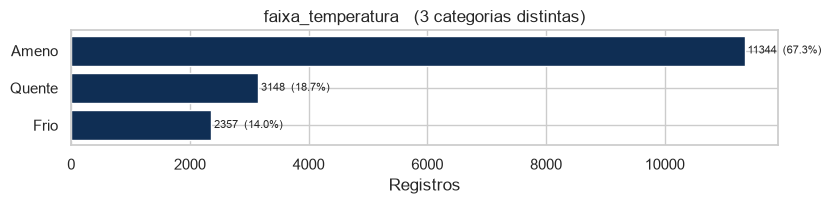

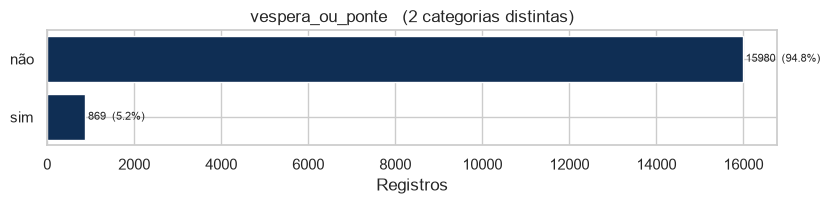

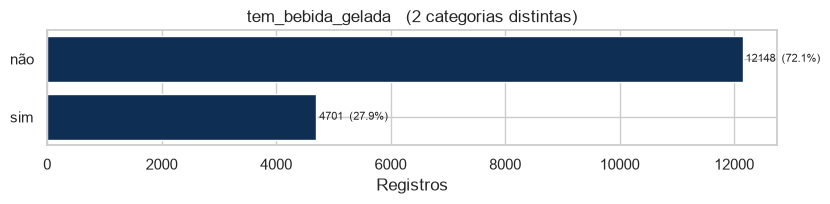

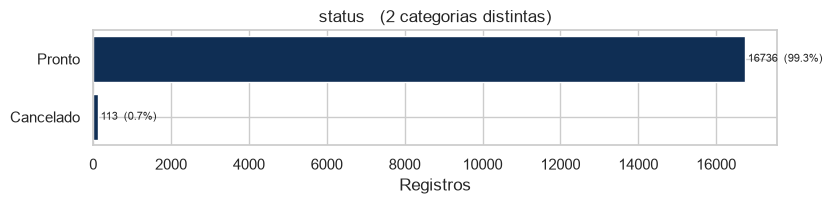

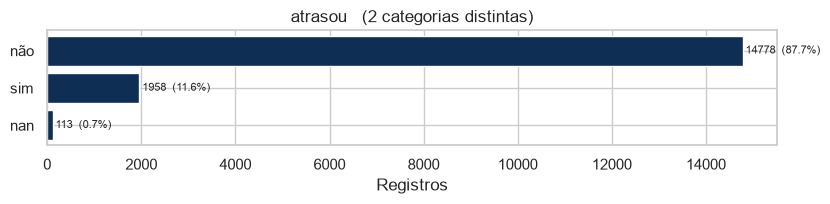

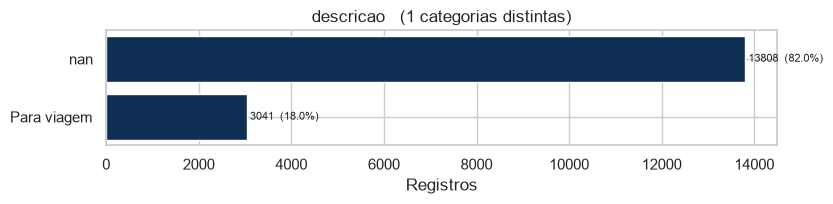

In [19]:
for c in COLS_CAT:
    vc = df[c].value_counts(dropna=False)
    if vc.empty:
        continue

    total_cat = df[c].nunique(dropna=True)
    if total_cat > MAX_CATEGORIAS:
        principais = vc.head(MAX_CATEGORIAS)
        outros = vc.iloc[MAX_CATEGORIAS:].sum()
        n_outros = len(vc) - MAX_CATEGORIAS
        principais = pd.concat([principais,
                                pd.Series({f"[Outros: {n_outros} categorias]": outros})])
    else:
        principais = vc

    fig, ax = plt.subplots(figsize=(8.5, max(2.2, 0.36 * len(principais))))
    ax.barh([str(i) for i in principais.index][::-1], principais.values[::-1],
            color="#0F2E54")
    ax.set_title(f"{c}   ({total_cat} categorias distintas)")
    ax.set_xlabel("Registros")
    for i, v in enumerate(principais.values[::-1]):
        ax.text(v, i, f" {v}  ({v/len(df)*100:.1f}%)", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

→ Categorias que aparecem escritas de formas diferentes (`SP`, `sp`, `São Paulo`) são o mesmo valor para o negócio e valores distintos para o Python. Se você vir isso aqui, volte à canonicalização da Aula 4 antes de prosseguir.

---
# 5) Outliers

Os três métodos vistos na Aula 6, aplicados lado a lado. Onde eles discordam, a decisão é sua — e precisa ser justificada.

In [20]:
def detecta_outliers(s):
    s = s.dropna()
    if len(s) < 4 or s.nunique() < 3:
        return None

    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr = ((s < lim_inf) | (s > lim_sup)).sum()

    dp = s.std()
    n_z = (abs(s - s.mean()) > 3 * dp).sum() if dp else 0

    mad = (s - s.median()).abs().median()
    n_zmod = (0.6745 * (s - s.median()).abs() / mad > 3.5).sum() if mad else 0

    return {
        "n": len(s),
        "lim_inf_iqr": round(lim_inf, 2),
        "lim_sup_iqr": round(lim_sup, 2),
        "outliers_iqr": n_iqr,
        "pct_iqr": round(n_iqr / len(s) * 100, 1),
        "outliers_z3": n_z,
        "outliers_zmod": n_zmod,
    }


linhas = []
for c in COLS_NUM:
    r = detecta_outliers(df[c])
    if r:
        linhas.append({"variavel": c, **r})

if linhas:
    display(pd.DataFrame(linhas).set_index("variavel"))
    print("Onde os três métodos discordam muito, a distribuição não é normal —")
    print("e o IQR costuma ser a leitura mais confiável.")
else:
    print("Nenhuma variável numérica com dados suficientes para detecção.")

,n,lim_inf_iqr,lim_sup_iqr,outliers_iqr,pct_iqr,outliers_z3,outliers_zmod
variavel,,,,,,,
pedidos_na_hora,16849,0.0,24.0,346,2.1,115,115
tempo_espera_min,16736,-4.3,14.1,684,4.1,303,609
valor_total,16849,-8.5,43.5,751,4.5,332,548
qtd_itens,16849,-0.5,3.5,635,3.8,180,0
hora,16849,5.0,21.0,0,0.0,0,0
temperatura_hora_c,16849,8.6,35.0,0,0.0,0,0
chuva_hora_mm,16849,0.0,0.0,4130,24.5,257,0
temp_max_dia_c,16849,10.8,37.2,0,0.0,0,0
chuva_dia_mm,16849,-1.8,3.0,2110,12.5,551,5244


Onde os três métodos discordam muito, a distribuição não é normal —
e o IQR costuma ser a leitura mais confiável.


In [21]:
# As linhas extremas de cada variável, para inspeção manual
for c in COLS_NUM:
    s = df[c].dropna()
    if len(s) < 4:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    fora = df[(df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)]
    if len(fora):
        print(f"\n{'='*55}\n{c}: {len(fora)} candidatos a outlier\n{'='*55}")
        display(fora.nlargest(min(5, len(fora)), c).head())


pedidos_na_hora: 346 candidatos a outlier


,id_pedido,dt_hr_pedido,pedidos_na_hora,tempo_espera_min,valor_total,qtd_itens,hora,temperatura_hora_c,chuva_hora_mm,temp_max_dia_c,chuva_dia_mm,tipo_dia,periodo,dia_semana,dia_chuvoso,condicao_dia,faixa_temperatura,vespera_ou_ponte,tem_bebida_gelada,status,atrasou,descricao
6752,6753,2026-06-14 14:03:35,30,4.1,16.0,1,14,21.8,0.1,21.8,0.7,fim de semana,tarde (após 14h),Domingo,não,Nublado,Ameno,não,sim,Pronto,não,NaN
6753,6754,2026-06-14 14:05:20,30,3.4,9.0,1,14,21.8,0.1,21.8,0.7,fim de semana,tarde (após 14h),Domingo,não,Nublado,Ameno,não,não,Pronto,não,NaN
6754,6755,2026-06-14 14:10:45,30,1.6,7.0,1,14,21.8,0.1,21.8,0.7,fim de semana,tarde (após 14h),Domingo,não,Nublado,Ameno,não,não,Pronto,não,NaN
6755,6756,2026-06-14 14:14:26,30,1.0,9.0,1,14,21.8,0.1,21.8,0.7,fim de semana,tarde (após 14h),Domingo,não,Nublado,Ameno,não,não,Pronto,não,NaN
6756,6757,2026-06-14 14:15:12,30,3.7,21.0,2,14,21.8,0.1,21.8,0.7,fim de semana,tarde (após 14h),Domingo,não,Nublado,Ameno,não,não,Pronto,não,NaN



tempo_espera_min: 684 candidatos a outlier


,id_pedido,dt_hr_pedido,pedidos_na_hora,tempo_espera_min,valor_total,qtd_itens,hora,temperatura_hora_c,chuva_hora_mm,temp_max_dia_c,chuva_dia_mm,tipo_dia,periodo,dia_semana,dia_chuvoso,condicao_dia,faixa_temperatura,vespera_ou_ponte,tem_bebida_gelada,status,atrasou,descricao
8678,8679,2026-07-04 15:23:21,18,34.4,26.0,2,15,17.9,0.1,18.0,0.1,fim de semana,tarde (após 14h),Sábado,não,Nublado,Frio,não,não,Pronto,sim,NaN
8673,8674,2026-07-04 15:10:51,18,34.3,14.0,1,15,17.9,0.1,18.0,0.1,fim de semana,tarde (após 14h),Sábado,não,Nublado,Frio,não,não,Pronto,sim,NaN
8671,8672,2026-07-04 15:07:31,18,34.2,9.0,1,15,17.9,0.1,18.0,0.1,fim de semana,tarde (após 14h),Sábado,não,Nublado,Frio,não,não,Pronto,sim,NaN
8670,8671,2026-07-04 15:06:50,18,34.0,27.0,3,15,17.9,0.1,18.0,0.1,fim de semana,tarde (após 14h),Sábado,não,Nublado,Frio,não,não,Pronto,sim,NaN
6773,6774,2026-06-14 14:31:35,30,32.7,14.0,1,14,21.8,0.1,21.8,0.7,fim de semana,tarde (após 14h),Domingo,não,Nublado,Ameno,não,não,Pronto,sim,NaN



valor_total: 751 candidatos a outlier


...

,id_pedido,dt_hr_pedido,pedidos_na_hora,tempo_espera_min,valor_total,qtd_itens,hora,temperatura_hora_c,chuva_hora_mm,temp_max_dia_c,chuva_dia_mm,tipo_dia,periodo,dia_semana,dia_chuvoso,condicao_dia,faixa_temperatura,vespera_ou_ponte,tem_bebida_gelada,status,atrasou,descricao
3000,3001,2026-05-03 09:55:29,7,9.8,66.0,7,9,17.9,0.9,18.5,1.2,fim de semana,manhã (até 12h),Domingo,não,Garoa,Frio,não,não,Pronto,não,NaN
3647,3648,2026-05-10 12:08:19,15,15.5,101.0,7,12,16.0,0.4,16.2,6.3,fim de semana,almoço (12h-14h),Domingo,sim,Chuva,Frio,não,sim,Pronto,sim,NaN
4448,4449,2026-05-20 12:56:33,9,14.4,76.0,7,12,19.9,0.1,20.7,0.7,dia útil,almoço (12h-14h),Quarta-feira,não,Nublado,Ameno,não,não,Pronto,sim,Para viagem
5027,5028,2026-05-26 13:30:33,9,7.9,70.0,7,13,24.7,0.0,25.9,1.8,dia útil,almoço (12h-14h),Terça-feira,não,Garoa,Ameno,não,não,Pronto,não,NaN
6485,6486,2026-06-12 09:52:44,12,13.8,87.0,7,9,16.0,0.0,20.2,2.8,dia útil,manhã (até 12h),Sexta-feira,não,Garoa,Ameno,não,sim,Pronto,sim,NaN



chuva_hora_mm: 4130 candidatos a outlier


,id_pedido,dt_hr_pedido,pedidos_na_hora,tempo_espera_min,valor_total,qtd_itens,hora,temperatura_hora_c,chuva_hora_mm,temp_max_dia_c,chuva_dia_mm,tipo_dia,periodo,dia_semana,dia_chuvoso,condicao_dia,faixa_temperatura,vespera_ou_ponte,tem_bebida_gelada,status,atrasou,descricao
53,54,2026-04-01 16:06:42,12,2.2,9.0,1,16,19.9,11.0,25.2,15.6,dia útil,tarde (após 14h),Quarta-feira,sim,Chuva forte,Ameno,não,não,Pronto,não,NaN
54,55,2026-04-01 16:08:19,12,4.2,22.0,2,16,19.9,11.0,25.2,15.6,dia útil,tarde (após 14h),Quarta-feira,sim,Chuva forte,Ameno,não,não,Pronto,não,NaN
55,56,2026-04-01 16:17:39,12,4.3,21.0,2,16,19.9,11.0,25.2,15.6,dia útil,tarde (após 14h),Quarta-feira,sim,Chuva forte,Ameno,não,não,Pronto,não,NaN
56,57,2026-04-01 16:27:10,12,3.8,17.0,1,16,19.9,11.0,25.2,15.6,dia útil,tarde (após 14h),Quarta-feira,sim,Chuva forte,Ameno,não,não,Pronto,não,NaN
57,58,2026-04-01 16:31:16,12,10.3,40.0,3,16,19.9,11.0,25.2,15.6,dia útil,tarde (após 14h),Quarta-feira,sim,Chuva forte,Ameno,não,não,Pronto,sim,NaN



chuva_dia_mm: 2110 candidatos a outlier


,id_pedido,dt_hr_pedido,pedidos_na_hora,tempo_espera_min,valor_total,qtd_itens,hora,temperatura_hora_c,chuva_hora_mm,temp_max_dia_c,chuva_dia_mm,tipo_dia,periodo,dia_semana,dia_chuvoso,condicao_dia,faixa_temperatura,vespera_ou_ponte,tem_bebida_gelada,status,atrasou,descricao
0,1,2026-04-01 09:00:47,8,4.4,37.0,3,9,20.4,0.0,25.2,15.6,dia útil,manhã (até 12h),Quarta-feira,sim,Chuva forte,Ameno,não,sim,Pronto,não,NaN
1,2,2026-04-01 09:05:30,8,3.2,14.0,1,9,20.4,0.0,25.2,15.6,dia útil,manhã (até 12h),Quarta-feira,sim,Chuva forte,Ameno,não,não,Pronto,não,NaN
2,3,2026-04-01 09:15:19,8,1.9,12.0,1,9,20.4,0.0,25.2,15.6,dia útil,manhã (até 12h),Quarta-feira,sim,Chuva forte,Ameno,não,não,Pronto,não,NaN
3,4,2026-04-01 09:42:28,8,3.0,16.0,1,9,20.4,0.0,25.2,15.6,dia útil,manhã (até 12h),Quarta-feira,sim,Chuva forte,Ameno,não,sim,Pronto,não,NaN
4,5,2026-04-01 09:44:45,8,2.1,10.0,1,9,20.4,0.0,25.2,15.6,dia útil,manhã (até 12h),Quarta-feira,sim,Chuva forte,Ameno,não,não,Pronto,não,NaN


→ Para cada candidato, responda a pergunta da Aula 6: **erro, evento raro ou subpopulação?**

- Erro → corrigir ou remover, documentando.
- Evento raro → manter, e reportar a métrica com e sem ele.
- Subpopulação → **segmentar**, não remover.

---
# 6) Séries temporais

Executa apenas se houver alguma coluna de data na base.

In [22]:
if COLS_DT:
    COL_TEMPO = COLS_DT[0]
    print(f"Coluna de tempo usada: {COL_TEMPO}")
    print(f"Período: {df[COL_TEMPO].min()}  ->  {df[COL_TEMPO].max()}")
    print(f"Registros sem data: {df[COL_TEMPO].isna().sum()}")

    tmp = df.dropna(subset=[COL_TEMPO]).set_index(COL_TEMPO).sort_index()
    dias = (tmp.index.max() - tmp.index.min()).days
    freq = "D" if dias <= 90 else ("W" if dias <= 730 else "MS")
    rotulo = {"D": "dia", "W": "semana", "MS": "mês"}[freq]
    print(f"Amplitude: {dias} dias -> agregando por {rotulo}")
else:
    print("Nenhuma coluna de data identificada. Seção 6 ignorada.")
    print("Se a sua base tem datas, informe-as em COLS_DATA na configuração.")

Coluna de tempo usada: dt_hr_pedido
Período: 2026-04-01 09:00:47  ->  2026-09-30 17:59:13
Registros sem data: 0
Amplitude: 182 dias -> agregando por semana


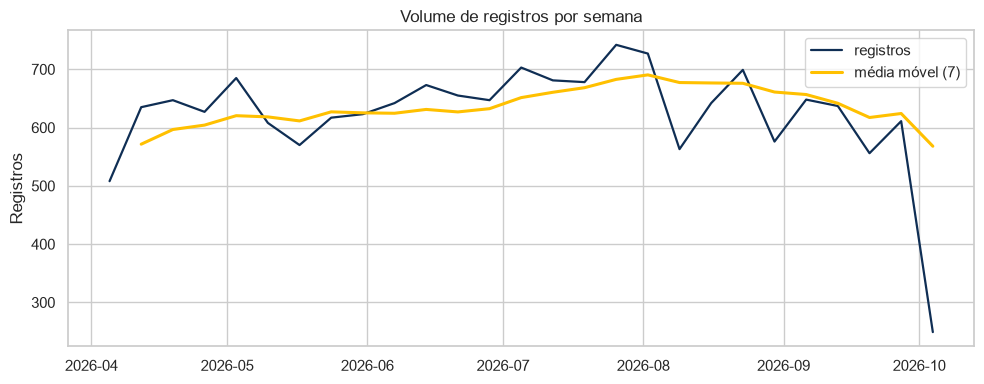

Procure: degraus (troca de sistema), buracos (falha de carga)
e o último período, que costuma estar incompleto.


In [23]:
if COLS_DT:
    volume = tmp.resample(freq).size()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(volume.index, volume.values, lw=1.6, color="#0F2E54", label="registros")
    if len(volume) >= 5:
        jan = max(3, min(7, len(volume) // 3))
        ax.plot(volume.index, volume.rolling(jan, min_periods=2).mean(),
                lw=2.2, color="#FFC000", label=f"média móvel ({jan})")
    ax.set_title(f"Volume de registros por {rotulo}")
    ax.set_ylabel("Registros")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Procure: degraus (troca de sistema), buracos (falha de carga)")
    print("e o último período, que costuma estar incompleto.")

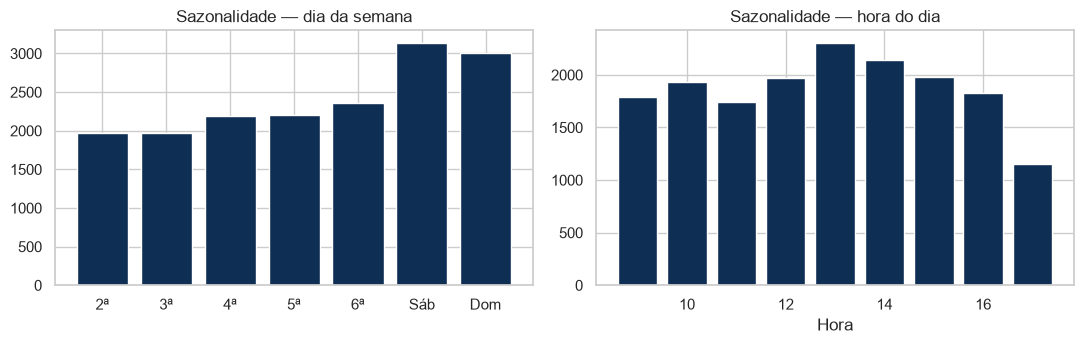

In [24]:
if COLS_DT:
    dias_pt = {"Monday": "2ª", "Tuesday": "3ª", "Wednesday": "4ª", "Thursday": "5ª",
               "Friday": "6ª", "Saturday": "Sáb", "Sunday": "Dom"}
    ordem = ["2ª", "3ª", "4ª", "5ª", "6ª", "Sáb", "Dom"]

    d = df.dropna(subset=[COL_TEMPO]).copy()
    d["_dia"] = d[COL_TEMPO].dt.day_name().map(dias_pt)
    d["_hora"] = d[COL_TEMPO].dt.hour

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    por_dia = d["_dia"].value_counts().reindex(ordem).fillna(0)
    axes[0].bar(por_dia.index, por_dia.values, color="#0F2E54")
    axes[0].set_title("Sazonalidade — dia da semana")

    if d["_hora"].nunique() > 1:
        por_hora = d["_hora"].value_counts().sort_index()
        axes[1].bar(por_hora.index, por_hora.values, color="#0F2E54")
        axes[1].set_title("Sazonalidade — hora do dia")
        axes[1].set_xlabel("Hora")
    else:
        axes[1].text(0.5, 0.5, "Sem informação de hora",
                     ha="center", va="center", transform=axes[1].transAxes)
        axes[1].axis("off")
    plt.tight_layout()
    plt.show()

---
# 7) Bivariada

A matriz de decisão da Aula 6 aplicada automaticamente: para cada par relevante, o gráfico correspondente ao par de tipos.

Pares numéricos com maior associação (Spearman, em módulo):


,,spearman_abs
temperatura_hora_c,temp_max_dia_c,0.851
valor_total,qtd_itens,0.826
chuva_hora_mm,chuva_dia_mm,0.664


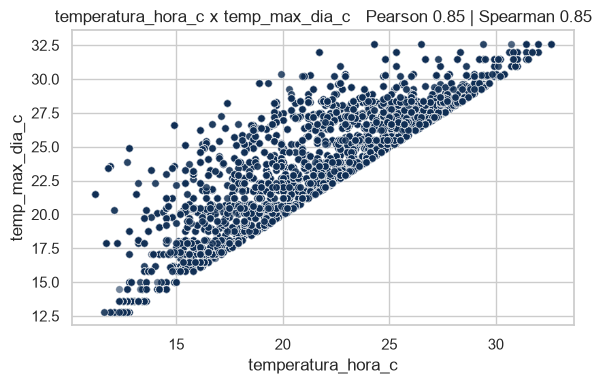

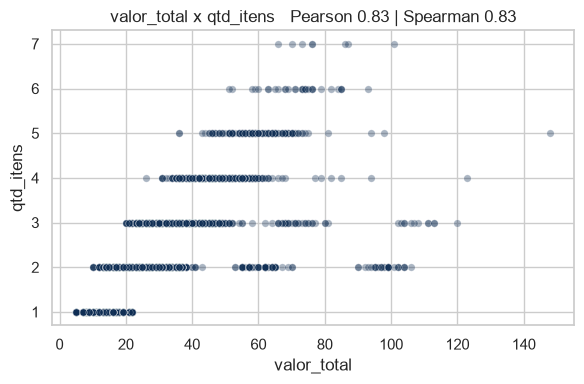

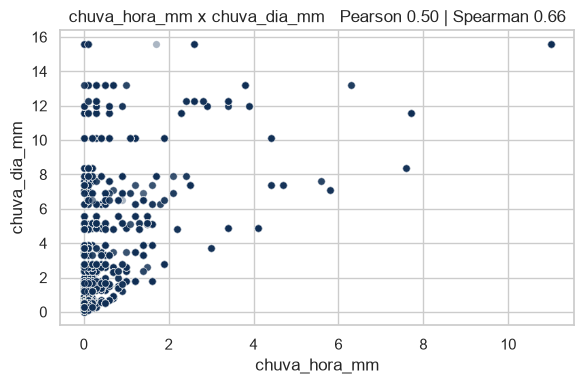

In [25]:
# Numérica x Numérica — dispersão dos pares mais correlacionados
if len(COLS_NUM) >= 2:
    corr_s = df[COLS_NUM].corr(method="spearman").abs()
    pares = (corr_s.where(np.triu(np.ones(corr_s.shape), k=1).astype(bool))
                   .stack().sort_values(ascending=False))
    top = pares.head(3)

    print("Pares numéricos com maior associação (Spearman, em módulo):")
    display(top.round(3).to_frame("spearman_abs"))

    for (a, b), _ in top.items():
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.scatterplot(data=df, x=a, y=b, alpha=0.35, s=28,
                        color="#0F2E54", ax=ax)
        p = df[[a, b]].corr().iloc[0, 1]
        sp = df[[a, b]].corr(method="spearman").iloc[0, 1]
        ax.set_title(f"{a} x {b}   Pearson {p:.2f} | Spearman {sp:.2f}")
        plt.tight_layout()
        plt.show()
else:
    print("Menos de duas variáveis numéricas — dispersão não se aplica.")

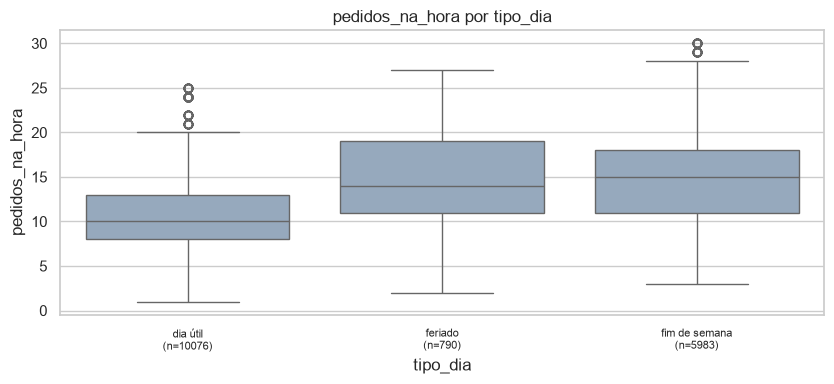

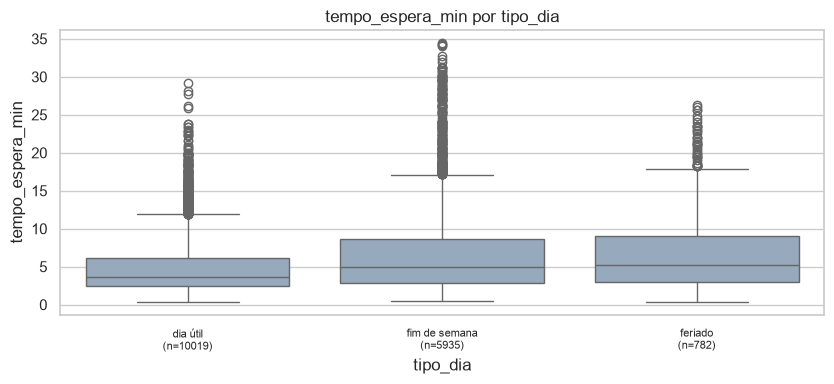

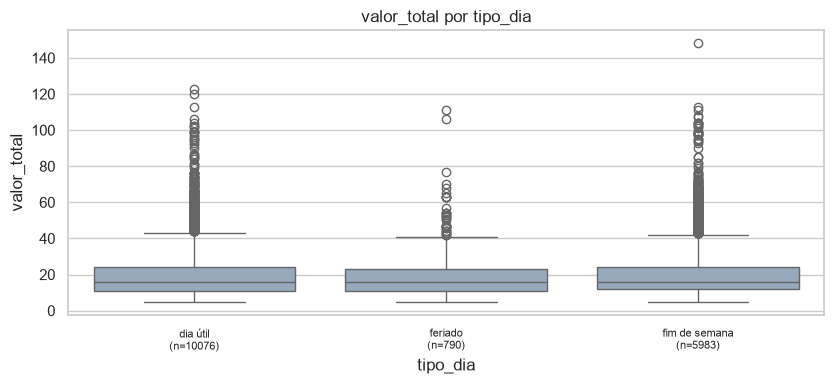

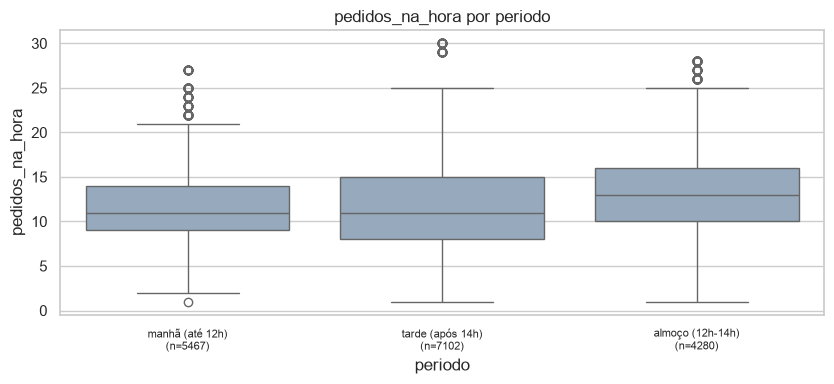

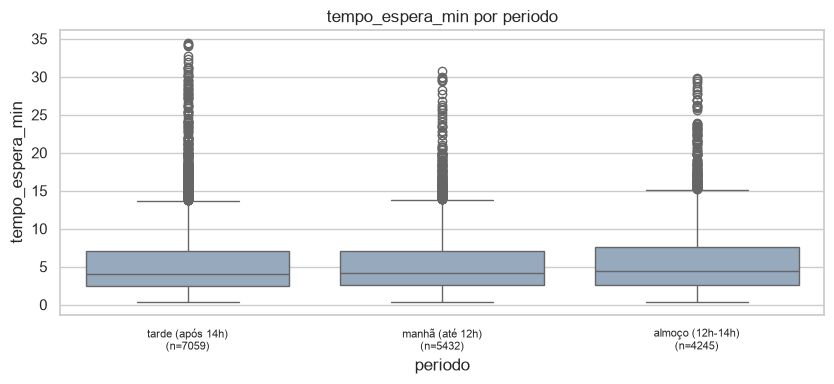

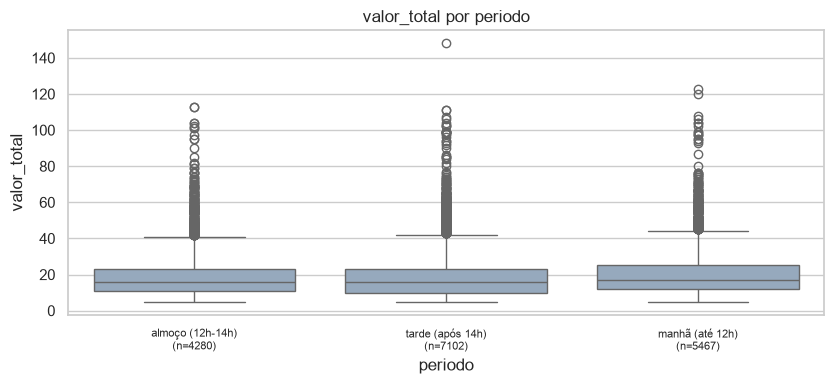

In [26]:
# Categórica x Numérica — boxplot por categoria
pares_feitos = 0
for cat in COLS_CAT:
    if not (2 <= df[cat].nunique() <= 12):
        continue
    for num in COLS_NUM[:3]:
        fig, ax = plt.subplots(figsize=(8.5, 4))
        ordem_cat = df.groupby(cat)[num].median().sort_values().index
        sns.boxplot(data=df, x=cat, y=num, order=ordem_cat,
                    color="#8FA9C4", ax=ax)
        ns = df.groupby(cat)[num].count().reindex(ordem_cat)
        ax.set_xticklabels([f"{c}\n(n={ns[c]})" for c in ordem_cat], fontsize=8)
        ax.set_title(f"{num} por {cat}")
        plt.tight_layout()
        plt.show()
        pares_feitos += 1
        if pares_feitos >= 6:
            break
    if pares_feitos >= 6:
        break

if pares_feitos == 0:
    print("Nenhum par categórica x numérica adequado encontrado.")

Contagem — tipo_dia x periodo


periodo,almoço (12h-14h),manhã (até 12h),tarde (após 14h)
tipo_dia,,,
dia útil,2561,3628,3887
feriado,212,221,357
fim de semana,1507,1618,2858



Proporção por linha (o que se deve ler)


periodo,almoço (12h-14h),manhã (até 12h),tarde (após 14h)
tipo_dia,,,
dia útil,25.4,36.0,38.6
feriado,26.8,28.0,45.2
fim de semana,25.2,27.0,47.8


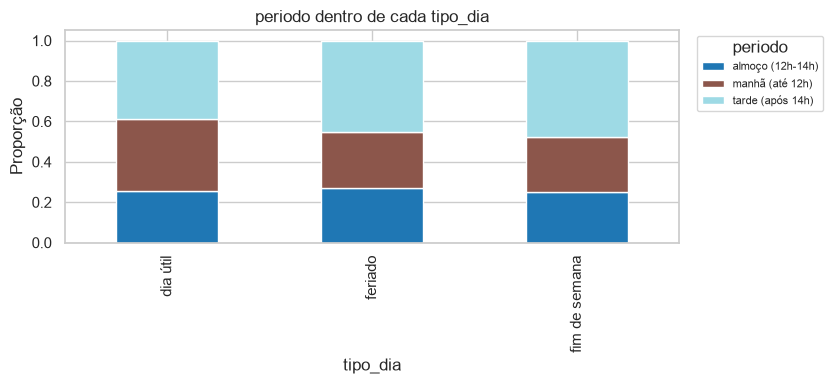

In [27]:
# Categórica x Categórica — proporção por linha, nunca contagem
cats_ok = [c for c in COLS_CAT if 2 <= df[c].nunique() <= 10]

if len(cats_ok) >= 2:
    a, b = cats_ok[0], cats_ok[1]
    ct_n = pd.crosstab(df[a], df[b])
    ct_p = pd.crosstab(df[a], df[b], normalize="index")

    print(f"Contagem — {a} x {b}")
    display(ct_n)
    print(f"\nProporção por linha (o que se deve ler)")
    display((ct_p * 100).round(1))

    fig, ax = plt.subplots(figsize=(8.5, 4))
    ct_p.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
    ax.set_ylabel("Proporção")
    ax.set_title(f"{b} dentro de cada {a}")
    ax.legend(title=b, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Menos de duas categóricas adequadas para tabela de contingência.")

---
# 8) Correlação

Pearson mede relação **linear**. Spearman mede relação **monotônica**, sobre os postos. Quando os dois discordam, existe relação — só não é uma reta.

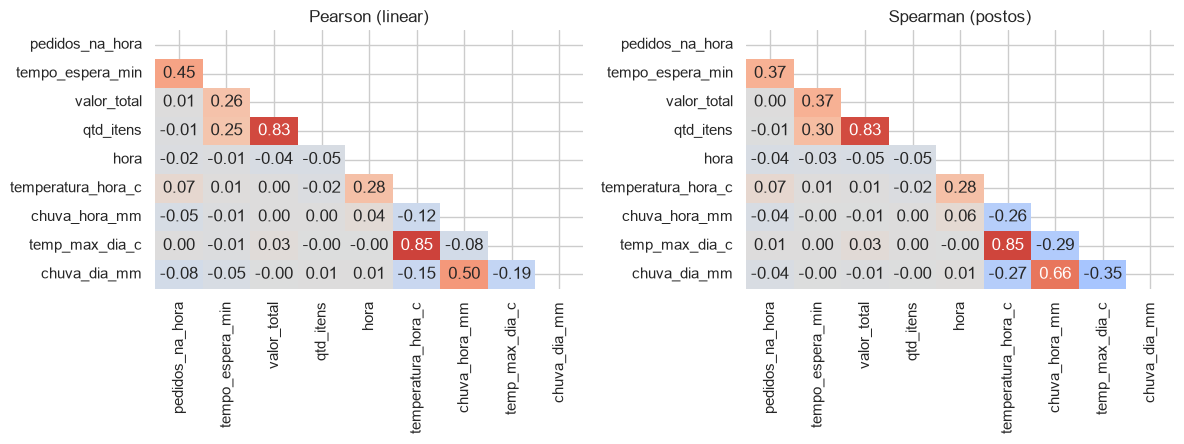

Pares em que Pearson e Spearman discordam (diferença > 0,15):


,,diferenca
chuva_hora_mm,temp_max_dia_c,0.211
temp_max_dia_c,chuva_dia_mm,0.163
chuva_hora_mm,chuva_dia_mm,0.159


Relação provavelmente não linear, ou influenciada por outliers.
Olhe o gráfico de dispersão antes de concluir qualquer coisa.


In [28]:
if len(COLS_NUM) >= 2:
    p = df[COLS_NUM].corr(method="pearson")
    s = df[COLS_NUM].corr(method="spearman")
    mask = np.triu(np.ones_like(p, dtype=bool))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    sns.heatmap(p, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, ax=axes[0], cbar=False)
    axes[0].set_title("Pearson (linear)")
    sns.heatmap(s, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, ax=axes[1], cbar=False)
    axes[1].set_title("Spearman (postos)")
    plt.tight_layout()
    plt.show()

    dif = (s - p).abs()
    dif = dif.where(np.triu(np.ones(dif.shape), k=1).astype(bool)).stack()
    fortes = dif[dif > 0.15].sort_values(ascending=False)
    if len(fortes):
        print("Pares em que Pearson e Spearman discordam (diferença > 0,15):")
        display(fortes.round(3).to_frame("diferenca"))
        print("Relação provavelmente não linear, ou influenciada por outliers.")
        print("Olhe o gráfico de dispersão antes de concluir qualquer coisa.")
    else:
        print("Pearson e Spearman concordam em todos os pares.")
else:
    print("Menos de duas variáveis numéricas.")

> **Lembrete de Anscombe:** nenhum número desta matriz entra no relatório sem o gráfico de dispersão correspondente ao lado.

---
# 9) Segmentação

A métrica principal por cada dimensão categórica — **sempre com o n ao lado**, como visto na Aula 6.

In [29]:
ALVO = COL_ALVO if COL_ALVO in df.columns else (COLS_NUM[0] if COLS_NUM else None)

if ALVO is None:
    print("Nenhuma variável-alvo disponível. Defina COL_ALVO na configuração.")
elif ALVO in COLS_NUM:
    print(f"Variável analisada: {ALVO} (numérica)\n")
    for cat in COLS_CAT:
        if not (2 <= df[cat].nunique() <= 20):
            continue
        seg = (df.groupby(cat)[ALVO]
                 .agg(n="size", media="mean", mediana="median", desvio="std")
                 .round(2)
                 .sort_values("media", ascending=False))
        seg["confiavel"] = np.where(seg["n"] >= MIN_N_SEGMENTO, "sim", "N BAIXO")
        print(f"--- {ALVO} por {cat} ---")
        display(seg)
else:
    print(f"Variável analisada: {ALVO} (categórica)\n")
    for cat in COLS_CAT:
        if cat == ALVO or not (2 <= df[cat].nunique() <= 20):
            continue
        ct = pd.crosstab(df[cat], df[ALVO], normalize="index").round(3) * 100
        ct["n"] = df[cat].value_counts()
        ct["confiavel"] = np.where(ct["n"] >= MIN_N_SEGMENTO, "sim", "N BAIXO")
        print(f"--- {ALVO} por {cat} (% por linha) ---")
        display(ct)

Variável analisada: atrasou (categórica)

--- atrasou por tipo_dia (% por linha) ---


atrasou,não,sim,n,confiavel
tipo_dia,,,,
dia útil,92.4,7.6,10076,sim
feriado,79.7,20.3,790,sim
fim de semana,82.5,17.5,5983,sim


--- atrasou por periodo (% por linha) ---


atrasou,não,sim,n,confiavel
periodo,,,,
almoço (12h-14h),86.9,13.1,4280,sim
manhã (até 12h),89.5,10.5,5467,sim
tarde (após 14h),88.2,11.8,7102,sim


--- atrasou por dia_semana (% por linha) ---


...

atrasou,não,sim,n,confiavel
vespera_ou_ponte,,,,
não,88.3,11.7,15980,sim
sim,89.1,10.9,869,sim


--- atrasou por tem_bebida_gelada (% por linha) ---


atrasou,não,sim,n,confiavel
tem_bebida_gelada,,,,
não,88.3,11.7,12148,sim
sim,88.3,11.7,4701,sim


--- atrasou por status (% por linha) ---


atrasou,não,sim,n,confiavel
status,,,,
Pronto,88.3,11.7,16736,sim


→ Segmentos marcados como **N BAIXO** têm poucos registros: a métrica deles oscila muito por construção e não sustenta recomendação. Trate-os separadamente, ou agrupe.

---
# 10) Multivariada

Facetas e o teste de Simpson.

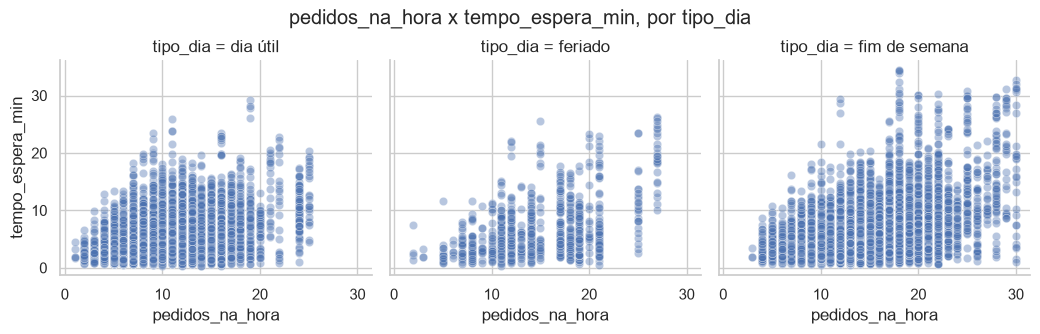

Eixos fixos em todos os painéis — é o que torna os painéis comparáveis.


In [30]:
# Facetas: a mesma relação, repetida dentro de cada valor de uma terceira variável
cats_faceta = [c for c in COLS_CAT if 2 <= df[c].nunique() <= 4]

if cats_faceta and len(COLS_NUM) >= 2:
    faceta = cats_faceta[0]
    x, y = COLS_NUM[0], COLS_NUM[1]
    g = sns.relplot(data=df, x=x, y=y, col=faceta, kind="scatter",
                    alpha=0.4, height=3.2, aspect=1.1,
                    facet_kws={"sharex": True, "sharey": True})
    g.figure.suptitle(f"{x} x {y}, por {faceta}", y=1.04)
    plt.show()
    print("Eixos fixos em todos os painéis — é o que torna os painéis comparáveis.")
else:
    print("Sem combinação adequada para facetas.")

In [31]:
def teste_simpson(df, grupo, segmento, metrica):
    """Compara a direção da métrica no agregado e dentro de cada segmento."""
    agregado = df.groupby(grupo)[metrica].mean()
    vencedor_geral = agregado.idxmax()

    por_seg = df.groupby([segmento, grupo])[metrica].mean().unstack()
    por_seg = por_seg.dropna()
    if por_seg.empty:
        return None

    vencedores = por_seg.idxmax(axis=1)
    invertidos = vencedores[vencedores != vencedor_geral]

    margem = round(float(agregado.max() - agregado.min()), 4)

    return {
        "margem_agregado": margem,
        "agregado": agregado.round(3),
        "por_segmento": por_seg.round(3),
        "composicao": pd.crosstab(df[grupo], df[segmento], normalize="index").round(3),
        "vencedor_geral": vencedor_geral,
        "segmentos_invertidos": list(invertidos.index),
    }


grupos_ok = [c for c in COLS_CAT if 2 <= df[c].nunique() <= 5]

# Se o alvo for categórico binário, vira uma métrica 0/1 — bem mais informativo
df_s = df.copy()
metrica = None
if COL_ALVO in df.columns and df[COL_ALVO].nunique(dropna=True) == 2:
    niveis = sorted(df[COL_ALVO].dropna().unique())
    df_s["_taxa_alvo"] = (df_s[COL_ALVO] == niveis[-1]).astype(float)
    metrica = "_taxa_alvo"
    print(f"Métrica: proporção de '{niveis[-1]}' em {COL_ALVO}")
elif COLS_NUM:
    metrica = COLS_NUM[0]
    print(f"Métrica: {metrica}")

grupos_ok = [c for c in grupos_ok if c != COL_ALVO]

if len(grupos_ok) >= 2 and metrica:
    grupo, segmento = grupos_ok[0], grupos_ok[1]
    df = df_s
    print(f"Grupos: {grupo}   |   Segmentado por: {segmento}\n")

    r = teste_simpson(df, grupo, segmento, metrica)
    if r:
        print("No agregado:")
        display(r["agregado"])
        print("\nPor segmento:")
        display(r["por_segmento"])
        print("\nComposição de cada grupo (é aqui que o paradoxo nasce):")
        display(r["composicao"])

        if r["segmentos_invertidos"]:
            print("\n" + "!" * 60)
            print(f"ATENÇÃO: no agregado vence '{r['vencedor_geral']}',")
            print(f"mas em {r['segmentos_invertidos']} o vencedor é outro.")
            print(f"Margem no agregado: {r['margem_agregado']}")
            print("Verifique se a diferença é grande o bastante para importar.")
            print("Isto é o paradoxo de Simpson. NÃO reporte apenas o agregado.")
            print("!" * 60)
        else:
            print("\nDireção consistente entre agregado e segmentos — sem inversão.")
else:
    print("Combinação insuficiente para o teste de Simpson.")
    print("Ele exige duas categóricas de poucos níveis e uma métrica numérica.")

Métrica: proporção de 'sim' em atrasou
Grupos: tipo_dia   |   Segmentado por: periodo

No agregado:


tipo_dia
dia útil         0.076
feriado          0.201
fim de semana    0.173
Name: _taxa_alvo, dtype: float64


Por segmento:


tipo_dia,dia útil,feriado,fim de semana
periodo,,,
almoço (12h-14h),0.087,0.311,0.177
manhã (até 12h),0.097,0.190,0.110
tarde (após 14h),0.048,0.143,0.208



Composição de cada grupo (é aqui que o paradoxo nasce):


periodo,almoço (12h-14h),manhã (até 12h),tarde (após 14h)
tipo_dia,,,
dia útil,0.254,0.36,0.386
feriado,0.268,0.28,0.452
fim de semana,0.252,0.27,0.478



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
ATENÇÃO: no agregado vence 'feriado',
mas em ['tarde (após 14h)'] o vencedor é outro.
Margem no agregado: 0.1257
Verifique se a diferença é grande o bastante para importar.
Isto é o paradoxo de Simpson. NÃO reporte apenas o agregado.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [32]:
def mostrar_simpson(base, grupo, segmento, metrica, titulo):
    print("=" * 70)
    print(titulo)
    print(f"Grupos: {grupo}  |  Segmentado por: {segmento}  |  Métrica: {metrica}")
    print("=" * 70)
    r = teste_simpson(base, grupo=grupo, segmento=segmento, metrica=metrica)
    if r is None:
        print("Sem dados suficientes.\n")
        return
    print("No agregado:")
    display(r["agregado"])
    print("Por segmento:")
    display(r["por_segmento"])
    print("Composição de cada grupo:")
    display(r["composicao"])
    print("n por combinação:")
    display(pd.crosstab(base[grupo], base[segmento]))
    if r["segmentos_invertidos"]:
        print(f"INVERSÃO: no agregado vence '{r['vencedor_geral']}', "
              f"mas em {r['segmentos_invertidos']} o vencedor é outro.\n")
    else:
        print("Sem inversão: a direção do agregado se mantém em todos os segmentos.\n")

diario = (df.assign(data=df["dt_hr_pedido"].dt.normalize())
            .groupby("data")
            .agg(pedidos_dia=("id_pedido", "size"),
                 dia_chuvoso=("dia_chuvoso", "first"),
                 tipo_dia=("tipo_dia", "first"))
            .reset_index())
mostrar_simpson(diario, "dia_chuvoso", "tipo_dia", "pedidos_dia",
                "1) Pedidos por dia: dias chuvosos x secos, dentro de cada tipo de dia")

prontos = df[df["status"] == "Pronto"].copy()
prontos["atrasou_num"] = (prontos["atrasou"] == "sim").astype(float)
mostrar_simpson(prontos, "tipo_dia", "periodo", "atrasou_num",
                "2) % de pedidos com mais de 10 min: tipo de dia, dentro de cada período")

1) Pedidos por dia: dias chuvosos x secos, dentro de cada tipo de dia
Grupos: dia_chuvoso  |  Segmentado por: tipo_dia  |  Métrica: pedidos_dia
No agregado:


dia_chuvoso
não    93.115
sim    82.500
Name: pedidos_dia, dtype: float64

Por segmento:


dia_chuvoso,não,sim
tipo_dia,,
dia útil,81.491,71.455
fim de semana,120.091,99.857


Composição de cada grupo:


...

Composição de cada grupo:


periodo,almoço (12h-14h),manhã (até 12h),tarde (após 14h)
tipo_dia,,,
dia útil,0.254,0.36,0.386
feriado,0.266,0.28,0.454
fim de semana,0.251,0.27,0.479


n por combinação:


periodo,almoço (12h-14h),manhã (até 12h),tarde (após 14h)
tipo_dia,,,
dia útil,2546,3610,3863
feriado,208,219,355
fim de semana,1491,1603,2841


INVERSÃO: no agregado vence 'feriado', mas em ['tarde (após 14h)'] o vencedor é outro.



→ O teste acima roda no primeiro par de categóricas encontrado. **Rode-o manualmente** para as combinações que fazem sentido no seu domínio — é o conhecimento do negócio que aponta onde procurar confundimento, não o código.

```python
r = teste_simpson(df, grupo="unidade", segmento="faixa_etaria", metrica="faltou")
```

---
# 11) Síntese

A EDA não termina em gráficos. Termina em **achados, hipóteses e decisões**.

Preencha a célula abaixo com as suas conclusões — é este texto, e não os gráficos, que vai para o relatório do PI.

In [33]:
SINTESE = """
ORIGEM DOS DADOS
   Os pedidos são simulados (a coleta real ainda não começou); clima e feriados são reais.
   Os padrões abaixo reproduzem as regras da simulação: esta EDA valida o método que será
   aplicado aos 6 meses de dados reais, não o comportamento dos clientes.

ACHADOS
   Procurados de propósito:
   1. Fins de semana e feriados têm mais pedidos por dia (117,3 e 112,9 contra 80,6 em dias úteis)
      e mais atraso (17,5% e 20,3% contra 7,6%). Gráficos: sazonalidade (seção 6) e boxplot por tipo_dia (seção 7).
   2. O atraso cresce com a carga da hora: 3,7% até 10 pedidos/h, 20,9% de 16 a 20 e 46,6% acima de 21,
      em todos os tipos de dia. Gráfico: facetas por tipo_dia (seção 10).
   3. Dias chuvosos têm menos pedidos também dentro de cada tipo de dia (81,5 -> 71,5 em dias úteis;
      120,1 -> 99,9 em fins de semana), sem inversão de Simpson. Teste 1 da célula de Simpson.
   4. Pedidos com bebida gelada: 11,2% em dias frios, 26,0% em amenos e 47,2% em quentes.
   Encontrados por acaso (hipóteses):
   5. Em dias úteis o maior atraso é na abertura (9h, 12,4%); nos fins de semana, das 13h às 15h (até 25,5%).
   6. descricao funciona como marcador de "Para viagem" (18,0%); o vazio significa consumo no local.
   7. Cancelamentos se concentram em horas cheias (1,1% acima de 20 pedidos/h contra 0,5% até 10).

HIPÓTESES
   1. A equipe de 2 pessoas satura entre 16 e 20 pedidos/h -> repetir com dados reais e registrar a equipe do turno.
   2. O atraso de abertura vem de fila acumulada -> registrar o início do preparo (fila x preparo).
   3. A chuva reduz clientes de passagem -> 6 meses reais e a previsão do dia anterior registrada.
   4. O calor desloca a venda para bebidas geladas -> mix real por faixa de temperatura.

DECISÕES DE TRATAMENTO
   1. Outliers de espera, carga e valor: manter (são o fenômeno ou subpopulação legítima); reportar medianas.
   2. Ausentes: métricas de tempo só com pedidos concluídos; cancelamentos reportados à parte;
      vazio de descricao recodificado como "consumo no local"; zeros de chuva mantidos como zero.
   3. Categorias raras: juntar "Chuva forte" (1 dia) com "Chuva"; feriados (7 dias) com aviso de n baixo.
   4. Redundâncias: usar só uma coluna de cada par (temperatura hora/dia; valor/itens);
      excluir a última semana, incompleta, das séries semanais.

LIMITAÇÕES
   1. Pedidos simulados: os padrões são as regras da simulação, não comportamento medido.
   2. Horário simulado 9h-18h; a cafeteria funciona das 10h às 18h30.
   3. Poucos casos raros em 6 meses: 7 feriados, 18 dias chuvosos, 1 dia de chuva forte.
   4. Fora da base (possíveis confundidores): equipe do turno, fila x preparo, eventos no bairro.
   5. Clima de reanálise em grade; a decisão real usará a previsão, que difere do observado.
   6. Quem desistiu antes de pedir não aparece: a demanda nos picos é subestimada.
"""

print(SINTESE)


ORIGEM DOS DADOS
   Os pedidos são simulados (a coleta real ainda não começou); clima e feriados são reais.
   Os padrões abaixo reproduzem as regras da simulação: esta EDA valida o método que será
   aplicado aos 6 meses de dados reais, não o comportamento dos clientes.

ACHADOS
   Procurados de propósito:
   1. Fins de semana e feriados têm mais pedidos por dia (117,3 e 112,9 contra 80,6 em dias úteis)
      e mais atraso (17,5% e 20,3% contra 7,6%). Gráficos: sazonalidade (seção 6) e boxplot por tipo_dia (seção 7).
   2. O atraso cresce com a carga da hora: 3,7% até 10 pedidos/h, 20,9% de 16 a 20 e 46,6% acima de 21,
      em todos os tipos de dia. Gráfico: facetas por tipo_dia (seção 10).
   3. Dias chuvosos têm menos pedidos também dentro de cada tipo de dia (81,5 -> 71,5 em dias úteis;
      120,1 -> 99,9 em fins de semana), sem inversão de Simpson. Teste 1 da célula de Simpson.
   4. Pedidos com bebida gelada: 11,2% em dias frios, 26,0% em amenos e 47,2% em quentes.
   Encontra

In [34]:
# Exportação da base tratada e do relatório de qualidade
df.to_csv("base_tratada.csv", index=False, encoding="utf-8-sig")
qualidade.to_csv("relatorio_qualidade.csv", encoding="utf-8-sig")

if COLS_NUM:
    desc.to_csv("estatistica_descritiva.csv", encoding="utf-8-sig")

print("Arquivos gerados:")
print("   base_tratada.csv")
print("   relatorio_qualidade.csv")
if COLS_NUM:
    print("   estatistica_descritiva.csv")

Arquivos gerados:
   base_tratada.csv
   relatorio_qualidade.csv
   estatistica_descritiva.csv


---

## Antes de entregar

- [ ] A configuração aponta para a base do seu PI, não para a base de exemplo
- [ ] A coluna `perda_pct` foi conferida: nenhuma conversão perdeu dados em silêncio
- [ ] Os nulos disfarçados encontrados foram acrescentados a `NA_EXTRA` e o notebook foi rodado de novo
- [ ] Cada candidato a outlier foi classificado: erro, evento raro ou subpopulação
- [ ] O teste de Simpson foi rodado nas combinações que fazem sentido no seu domínio
- [ ] A célula de síntese está preenchida

---

*SPTech School — Análise de Dados — Prof. Rodrigo Fernandes*